# Аналіз споживання алкоголю в США (1977–2023)
**Джерело даних:** NIAAA — Apparent Per Capita Consumption dataset

---

In [ ]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Налаштування відображення таблиць
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)


---
## Завдання 1. Підготовка набору даних

### 1.1 Завантаження набору даних

In [ ]:
df = pd.read_csv('./niaaa_apparent_per_capita_consumption_1977_2023.csv')
print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} колонок")
print(f"Колонки: {list(df.columns)}")
df.head()

Розмір датасету: 2632 рядків, 11 колонок
Колонки: ['state', 'state_name', 'year', 'ethanol_beer_gallons_per_capita', 'ethanol_wine_gallons_per_capita', 'ethanol_spirit_gallons_per_capita', 'ethanol_all_drinks_gallons_per_capita', 'number_of_beers', 'number_of_glasses_wine', 'number_of_shots_liquor', 'number_of_drinks_total']


,state,state_name,year,ethanol_beer_gallons_per_capita,ethanol_wine_gallons_per_capita,ethanol_spirit_gallons_per_capita,ethanol_all_drinks_gallons_per_capita,number_of_beers,number_of_glasses_wine,number_of_shots_liquor,number_of_drinks_total
0,alabama,Alabama,1977,0.9700,0.1200,0.8200,1.9200,229.9259,23.8140,170.2514,409.6000
1,alabama,Alabama,1978,0.9500,0.1200,0.8500,1.9200,225.1852,23.8140,176.4801,409.6000
2,alabama,Alabama,1979,0.9600,0.1200,0.8200,1.9000,227.5556,23.8140,170.2514,405.3333
3,alabama,Alabama,1980,0.9500,0.1600,0.7400,1.8600,225.1852,31.7519,153.6415,396.8000
4,alabama,Alabama,1981,1.0000,0.1900,0.7300,1.9100,237.0370,37.7054,151.5653,407.4667


### 1.2 Очищення — видалення зайвих стовпців

In [ ]:
cols_to_keep = [
    'state', 'state_name', 'year',
    'ethanol_beer_gallons_per_capita',
    'ethanol_wine_gallons_per_capita',
    'ethanol_spirit_gallons_per_capita',
    'ethanol_all_drinks_gallons_per_capita'
]
df = df[cols_to_keep]
print(f"Залишені колонки: {list(df.columns)}")
df.head()

Залишені колонки: ['state', 'state_name', 'year', 'ethanol_beer_gallons_per_capita', 'ethanol_wine_gallons_per_capita', 'ethanol_spirit_gallons_per_capita', 'ethanol_all_drinks_gallons_per_capita']


,state,state_name,year,ethanol_beer_gallons_per_capita,ethanol_wine_gallons_per_capita,ethanol_spirit_gallons_per_capita,ethanol_all_drinks_gallons_per_capita
0,alabama,Alabama,1977,0.9700,0.1200,0.8200,1.9200
1,alabama,Alabama,1978,0.9500,0.1200,0.8500,1.9200
2,alabama,Alabama,1979,0.9600,0.1200,0.8200,1.9000
3,alabama,Alabama,1980,0.9500,0.1600,0.7400,1.8600
4,alabama,Alabama,1981,1.0000,0.1900,0.7300,1.9100


### 1.3 Обробка пропущених значень

In [ ]:
print("Пропущені значення до очищення:")
display(df.isnull().sum().rename('Кількість NaN').to_frame())

df = df.dropna(subset=['ethanol_all_drinks_gallons_per_capita'])
print(f"\nРядків після видалення NaN у ключовому стовпці: {len(df)}")

Пропущені значення до очищення:


,Кількість NaN
state,0
state_name,0
year,0
ethanol_beer_gallons_per_capita,0
ethanol_wine_gallons_per_capita,0
ethanol_spirit_gallons_per_capita,0
ethanol_all_drinks_gallons_per_capita,0



Рядків після видалення NaN у ключовому стовпці: 2632


### 1.4 Форматування типів даних

In [ ]:
df['year'] = df['year'].astype('int32')
df['state'] = df['state'].astype('category')
df['state_name'] = df['state_name'].astype('category')

dtype_info = pd.DataFrame({
    'Стовпець': ['year', 'state', 'state_name'],
    'Тип після форматування': [str(df['year'].dtype), str(df['state'].dtype), str(df['state_name'].dtype)]
})
display(dtype_info.style.set_caption("Типи даних після перетворення").hide(axis='index'))

Стовпець,Тип після форматування
year,int32
state,category
state_name,category


---
## Завдання 2. Дослідження набору даних

### 2.1 Загальна кількість записів

In [ ]:
print(f"Загальна кількість записів після очищення: {len(df)}")

Загальна кількість записів після очищення: 2632


### 2.2 Робота з числовими показниками

In [ ]:
threshold = 2.5
high_consumption = df[df['ethanol_all_drinks_gallons_per_capita'] > threshold]
print(f"Кількість записів із загальним споживанням > {threshold}: {len(high_consumption)}")

avg_beer = high_consumption['ethanol_beer_gallons_per_capita'].mean()
print(f"Середнє споживання пива для цієї вибірки: {avg_beer:.4f} галонів на душу населення")

Кількість записів із загальним споживанням > 2.5: 1006
Середнє споживання пива для цієї вибірки: 1.4040 галонів на душу населення


**Топ-10 записів з найбільшим загальним споживанням алкоголю:**

In [ ]:
top10 = df.nlargest(10, 'ethanol_all_drinks_gallons_per_capita')[
    ['state_name', 'year', 'ethanol_all_drinks_gallons_per_capita']
].reset_index(drop=True)
top10.index += 1

top10.columns = ['Штат', 'Рік', 'Споживання (гал/особу)']
top10.style\
    .background_gradient(subset=['Споживання (гал/особу)'], cmap='Reds')\
    .format({'Споживання (гал/особу)': '{:.4f}'})\
    .set_caption("Топ-10 за споживанням алкоголю")

,Штат,Рік,Споживання (гал/особу)
1,Nevada,1977,6.3200
2,Nevada,1978,6.1300
3,Nevada,1979,5.8300
4,Nevada,1980,5.7500
5,Nevada,1981,5.5900
6,District Of Columbia,1981,5.4200
7,District Of Columbia,1980,5.4100
8,District Of Columbia,1977,5.3700
9,New Hampshire,1978,5.3600
10,District Of Columbia,1978,5.3300


### 2.3 Дослідження категорій та тексту

In [ ]:
cond1 = df['state_name'] == 'New York'
cond2 = df['state_name'].str.contains('New', na=False)

results = pd.DataFrame({
    'Умова': [
        'New York (точний збіг)',
        'Містить "New" (частковий)',
        'Обидві умови',
        'Умова 1, але НЕ умова 2',
        'Жодна умова'
    ],
    'Кількість записів': [
        cond1.sum(),
        cond2.sum(),
        (cond1 & cond2).sum(),
        (cond1 & ~cond2).sum(),
        (~cond1 & ~cond2).sum()
    ]
})

fraction = (cond1 & ~cond2).sum() / len(df)
print(f"Частка 'умова 1, але НЕ умова 2': {fraction:.4f} ({fraction*100:.2f}%)")
display(results.style.hide(axis='index').set_caption("Фільтрація за назвою штату"))

Частка 'умова 1, але НЕ умова 2': 0.0000 (0.00%)


Умова,Кількість записів
New York (точний збіг),47
"Містить ""New"" (частковий)",188
Обидві умови,47
"Умова 1, але НЕ умова 2",0
Жодна умова,2444


### 2.4 Числові діапазони та зрізи

In [ ]:
count_year_2000 = (df['year'] == 2000).sum()
count_range = ((df['year'] >= 1990) & (df['year'] <= 2000)).sum()

ranges_df = pd.DataFrame({
    'Фільтр': ['Точно 2000 рік', 'Діапазон 1990–2000'],
    'Кількість записів': [count_year_2000, count_range]
})
display(ranges_df.style.hide(axis='index').set_caption("Фільтрація за роком"))
print(f"Кількість для 2000 > кількість за 1990–2000? {count_year_2000 > count_range}")

Фільтр,Кількість записів
Точно 2000 рік,56
Діапазон 1990–2000,616


Кількість для 2000 > кількість за 1990–2000? False


### 2.5 Комбіновані фільтри та оцінки

In [ ]:
significant = df[df['ethanol_all_drinks_gallons_per_capita'] > 1.5]
print(f"Кількість 'значущих' записів (споживання > 1.5): {len(significant)}")

top5 = significant.nlargest(5, 'ethanol_all_drinks_gallons_per_capita')[
    ['state_name', 'year', 'ethanol_all_drinks_gallons_per_capita']
].reset_index(drop=True)
top5.index += 1
top5.columns = ['Штат', 'Рік', 'Споживання (гал/особу)']

display(top5.style
    .background_gradient(subset=['Споживання (гал/особу)'], cmap='Oranges')
    .format({'Споживання (гал/особу)': '{:.4f}'})
    .set_caption("Топ-5 зі значущої вибірки"))

top10_wine = df.nlargest(10, 'ethanol_wine_gallons_per_capita')
median_spirit = top10_wine['ethanol_spirit_gallons_per_capita'].median()
print(f"\nМедіана споживання спиртного для топ-10 за вином: {median_spirit:.4f}")

Кількість 'значущих' записів (споживання > 1.5): 2595


,Штат,Рік,Споживання (гал/особу)
1,Nevada,1977,6.3200
2,Nevada,1978,6.1300
3,Nevada,1979,5.8300
4,Nevada,1980,5.7500
5,Nevada,1981,5.5900



Медіана споживання спиртного для топ-10 за вином: 0.8250


### 2.6 Порівняння груп: Nevada vs Utah

In [ ]:
df_nevada = df[df['state_name'] == 'Nevada']
df_utah = df[df['state_name'] == 'Utah']

comparison = pd.DataFrame({
    'Штат': ['Nevada', 'Utah'],
    'Кількість записів': [len(df_nevada), len(df_utah)],
    'Середнє споживання': [
        df_nevada['ethanol_all_drinks_gallons_per_capita'].mean(),
        df_utah['ethanol_all_drinks_gallons_per_capita'].mean()
    ]
})

comparison.style\
    .background_gradient(subset=['Середнє споживання'], cmap='coolwarm')\
    .format({'Середнє споживання': '{:.4f}'})\
    .hide(axis='index')\
    .set_caption("Порівняння Nevada vs Utah")

Штат,Кількість записів,Середнє споживання
Nevada,47,4.1089
Utah,47,1.3923


### 2.7 Комплексні завдання

In [ ]:
complex_filter = df[
    ((df['year'] > 2000) & (df['ethanol_beer_gallons_per_capita'] > 1.0)) |
    (df['ethanol_wine_gallons_per_capita'] > 0.5) &
    ~(df['state'] == 'utah')
]
print(f"Кількість записів після складного фільтру (AND + OR + NOT): {len(complex_filter)}")

Кількість записів після складного фільтру (AND + OR + NOT): 1274


### Графік: тренд споживання алкоголю по роках

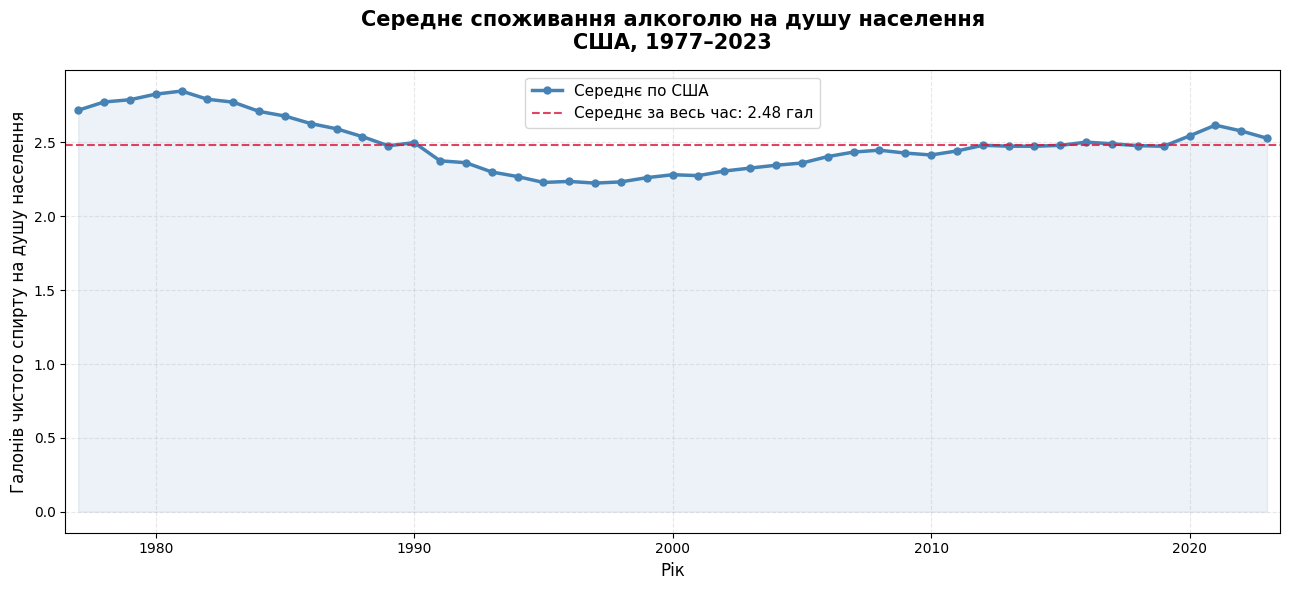

In [ ]:
yearly_avg = df.groupby('year')['ethanol_all_drinks_gallons_per_capita'].mean()

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(yearly_avg.index, yearly_avg.values, color='steelblue', linewidth=2.5, marker='o', markersize=5, label='Середнє по США')
ax.fill_between(yearly_avg.index, yearly_avg.values, alpha=0.1, color='steelblue')
ax.axhline(y=yearly_avg.mean(), color='crimson', linestyle='--', linewidth=1.5, alpha=0.8,
           label=f'Середнє за весь час: {yearly_avg.mean():.2f} гал')
ax.set_title('Середнє споживання алкоголю на душу населення\nСША, 1977–2023', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Рік', fontsize=12)
ax.set_ylabel('Галонів чистого спирту на душу населення', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)
ax.set_xlim(yearly_avg.index.min() - 0.5, yearly_avg.index.max() + 0.5)
plt.tight_layout()
plt.show()